<a href="https://colab.research.google.com/github/mertcandemirr/sql-practice/blob/main/tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
!pip install ucimlrepo

In [12]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    StratifiedKFold,
    cross_val_score
)

from sklearn.tree import (
    DecisionTreeClassifier,
    plot_tree
)

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

In [13]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

In [14]:
wine = fetch_ucirepo(id=186)

X = wine.data.features
y = wine.data.targets

In [15]:
wine = fetch_ucirepo(id=186)

X = wine.data.features
y = wine.data.targets

In [16]:
y = (y["quality"] >= 6).astype(int)

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=SEED,
    stratify=y
)

In [18]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)

In [19]:
dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=SEED),

    param_grid={
        "criterion": ["gini", "entropy"],
        "splitter": ["best", "random"],
        "max_depth": [3, 4, 5, 6, 8, None],
        "min_samples_leaf": [1, 2, 5, 10]
    },

    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

In [20]:
dt_grid.fit(X_train, y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=DecisionTreeClassifier(random_state=42), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [3, 4, 5, 6, 8, None],
                         'min_samples_leaf': [1, 2, 5, 10],
                         'splitter': ['best', 'random']},
             scoring='accuracy')

In [21]:
dt = dt_grid.best_estimator_

print("Decision Tree en iyi parametreler:")
print(dt_grid.best_params_)

Decision Tree en iyi parametreler:
{'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 1, 'splitter': 'best'}


In [22]:
rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=SEED),

    param_grid={
        "n_estimators": [100, 200],
        "max_depth": [5, 7],
        "min_samples_leaf": [1, 2],
        "min_samples_split": [2, 5],
        "max_features": ["sqrt", "log2"],
        "criterion": ["gini", "entropy"],
        "bootstrap": [True, False]
    },

    cv=cv,
    scoring="accuracy",
    n_jobs=-1,
    verbose=3
)

In [24]:
rf_grid.fit(X_train, y_train)

rf = rf_grid.best_estimator_

print("Random Forest en iyi parametreler:")
print(rf_grid.best_params_)

Fitting 5 folds for each of 128 candidates, totalling 640 fits
Random Forest en iyi parametreler:
{'bootstrap': False, 'criterion': 'gini', 'max_depth': 7, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


In [25]:
for name, model in [
    ("Decision Tree", dt),
    ("Random Forest", rf)
]:

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    cv_scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring="accuracy"
    )

    print(f"\n======== {name} ========")

    print(
        f"Test doğruluğu: "
        f"{accuracy_score(y_test, y_pred):.4f}"
    )

    print(
        f"Ortalama 5 katlı CV doğruluğu: "
        f"{np.mean(cv_scores):.4f}"
    )


======== Decision Tree ========
Test doğruluğu: 0.7762
Ortalama 5 katlı CV doğruluğu: 0.7651

======== Random Forest ========
Test doğruluğu: 0.7808
Ortalama 5 katlı CV doğruluğu: 0.7758


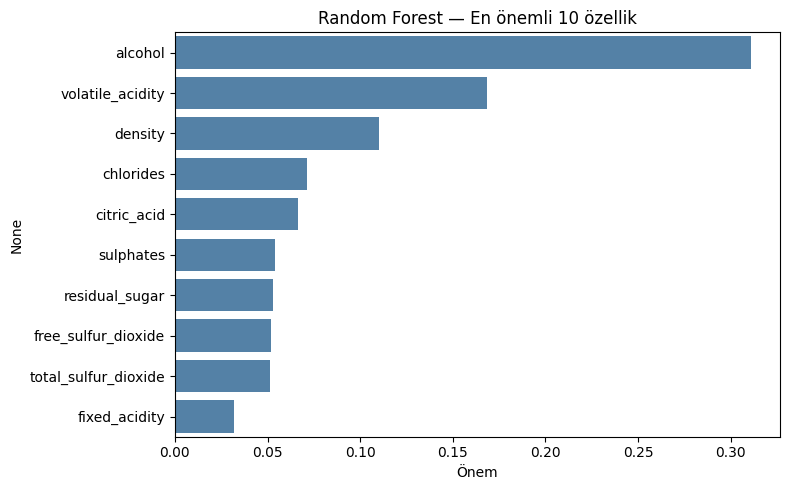

In [26]:
imp = pd.Series(
    rf.feature_importances_,
    index=X.columns
).nlargest(10)

plt.figure(figsize=(8, 5))

sns.barplot(
    x=imp.values,
    y=imp.index,
    color="steelblue"
)

plt.xlabel("Önem")
plt.title("Random Forest — En önemli 10 özellik")

plt.tight_layout()
plt.show()

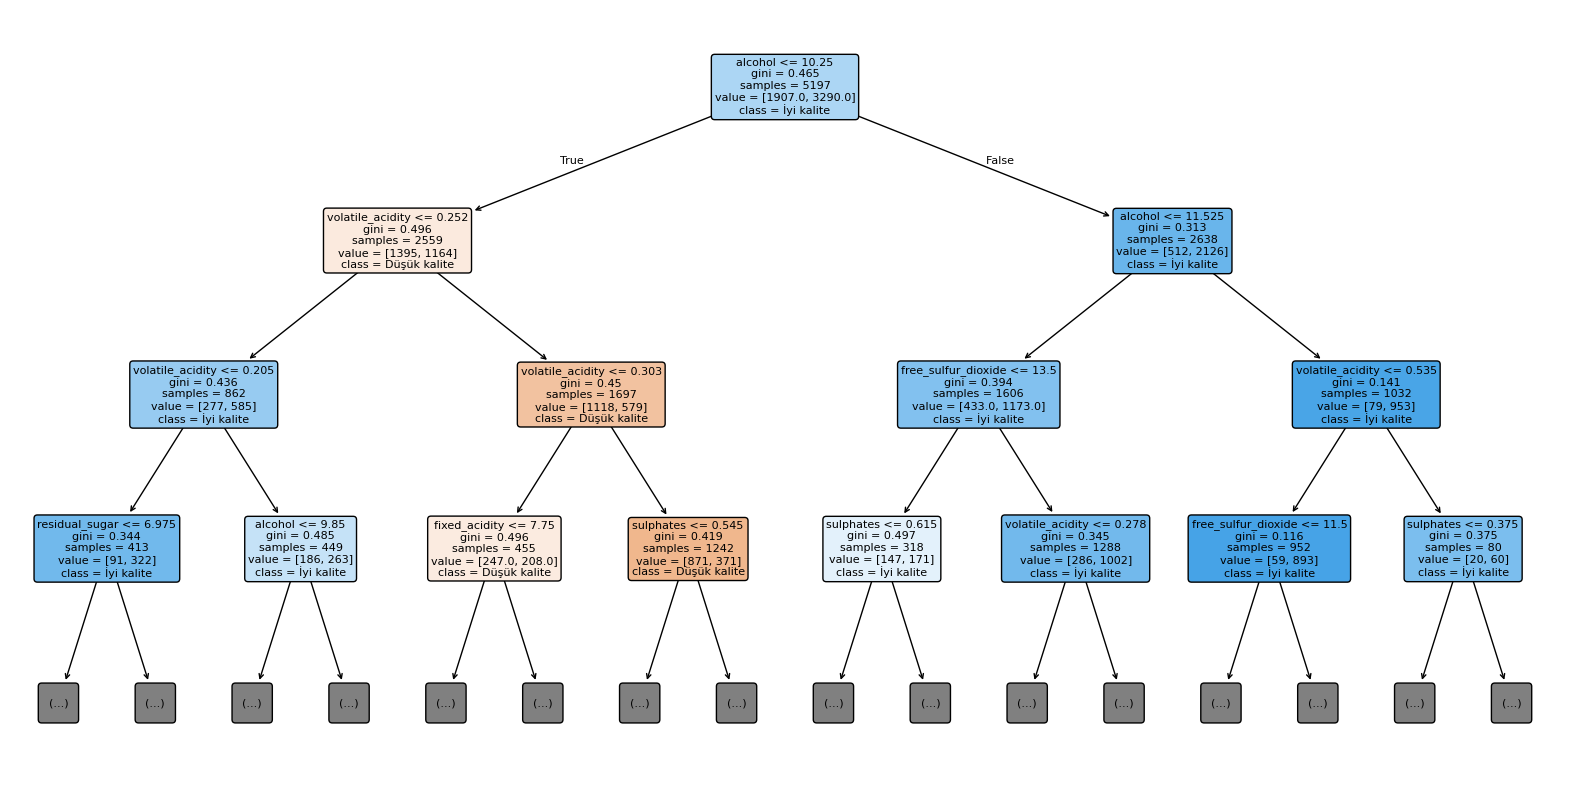

In [27]:
plt.figure(figsize=(20, 10))

plot_tree(
    dt,
    feature_names=X.columns,
    class_names=["Düşük kalite", "İyi kalite"],
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=8
)

plt.show()